# FPL Points Prediction Workflow

This notebook loads pre-trained models and artifacts saved from `final.ipynb` and runs the full prediction pipeline:

1. **Load saved models & configuration** (direct, PCA)
2. **Load & preprocess data** (from featured CSV or raw data)
3. **Predict points** for any season/gameweek
4. **Compare predicted vs actual** values
5. **Predict for a single player** given their stats
6. **Visualize** model performance

In [15]:
import pandas as pd
import numpy as np
import joblib
import json
import os
import warnings
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

warnings.filterwarnings('ignore')

SAVE_DIR = 'saved_models'
print(f"Models directory: {os.path.abspath(SAVE_DIR)}")
print(f"Directory exists: {os.path.exists(SAVE_DIR)}")

Models directory: c:\Users\LENOVO\OneDrive\Desktop\Y3S1\DATA_MINING\PROJECT\saved_models
Directory exists: True


## 1. Load Saved Models & Artifacts

In [16]:
# ── Load configuration ──────────────────────────────────────────────
config = joblib.load(os.path.join(SAVE_DIR, 'config.joblib'))

training_features    = config['training_features']
POSITION_FEATURES    = config['POSITION_FEATURES']
STATS_TO_PREDICT     = config['STATS_TO_PREDICT']
ALL_STATS_TO_PREDICT = config['ALL_STATS_TO_PREDICT']
exclude_from_training = config['exclude_from_training']

print(f"Training features loaded: {len(training_features)}")
print(f"Position feature counts: {', '.join(f'{k}={len(v)}' for k, v in POSITION_FEATURES.items())}")
print(f"Stats to predict: {list(STATS_TO_PREDICT.keys())}")

Training features loaded: 229
Position feature counts: GK=148, DEF=201, MID=201, FWD=201
Stats to predict: ['GK', 'DEF', 'MID', 'FWD']


In [17]:
# ── Load label encoders ─────────────────────────────────────────────
label_encoders = joblib.load(os.path.join(SAVE_DIR, 'label_encoders.joblib'))
print(f"Loaded {len(label_encoders)} label encoders: {list(label_encoders.keys())}")

Loaded 10 label encoders: ['opponent_team', 'position', 'team', 'season', 'was_home_prev_1', 'was_home_prev_2', 'was_home_prev_3', 'was_home_prev_4', 'was_home_prev_5', 'season_stage']


In [18]:
# ── Load DIRECT per-position models ─────────────────────────────────
with open(os.path.join(SAVE_DIR, 'direct', 'meta.json')) as f:
    direct_meta = json.load(f)

direct_models = {}   # {position: {scaler, features, models: {name: model}, best_model}}

for position, meta in direct_meta.items():
    pos_dir = os.path.join(SAVE_DIR, 'direct', position)

    with open(os.path.join(pos_dir, 'features.json')) as f:
        features = json.load(f)

    scaler = joblib.load(os.path.join(pos_dir, 'scaler.joblib'))

    models = {}
    for model_name in meta['models_saved']:
        models[model_name] = joblib.load(os.path.join(pos_dir, f'{model_name}.joblib'))

    direct_models[position] = {
        'scaler': scaler,
        'features': features,
        'models': models,
        'best_model': meta['best_model'],
        'best_test_r2': meta['best_test_r2'],
    }
    print(f"{position}: best={meta['best_model']} (R2={meta['best_test_r2']:.4f}), "
          f"{len(features)} features, {len(models)} models")

GK: best=XGBoost (R2=0.2232), 1 features, 4 models
DEF: best=XGBoost (R2=0.0888), 1 features, 4 models
MID: best=XGBoost (R2=0.1323), 1 features, 4 models
FWD: best=XGBoost (R2=0.1320), 1 features, 4 models


In [19]:
# ── Load PCA per-position models ────────────────────────────────────
with open(os.path.join(SAVE_DIR, 'pca_models', 'meta.json')) as f:
    pca_meta = json.load(f)

pca_models = {}  # {position: {models: {name: model}, best_model, n_components}}

for position, meta in pca_meta.items():
    pos_dir = os.path.join(SAVE_DIR, 'pca_models', position)

    models = {}
    for model_name in meta['models_saved']:
        models[model_name] = joblib.load(os.path.join(pos_dir, f'{model_name}.joblib'))

    pca_models[position] = {
        'models': models,
        'best_model': meta['best_model'],
        'best_test_r2': meta['best_test_r2'],
        'n_pca_components': meta['n_pca_components'],
    }
    print(f"{position}: best={meta['best_model']} (R2={meta['best_test_r2']:.4f}), "
          f"PCA dims={meta['n_pca_components']}")

GK: best=XGBoost (R2=0.4437), PCA dims=63
DEF: best=Ridge (R2=0.2746), PCA dims=83
MID: best=Ridge (R2=0.3187), PCA dims=81
FWD: best=ElasticNet (R2=0.2897), PCA dims=80


In [20]:
# ── Load PCA artifacts (transformers & scalers) ─────────────────────
pca_artifacts = {}  # {position: {pca_model, pca_scaler, config}}

for position in ['GK', 'DEF', 'MID', 'FWD']:
    pos_dir = os.path.join(SAVE_DIR, 'pca_artifacts', position)
    if not os.path.exists(pos_dir):
        continue

    pca_model  = joblib.load(os.path.join(pos_dir, 'pca_model.joblib'))
    pca_scaler = joblib.load(os.path.join(pos_dir, 'pca_scaler.joblib'))

    with open(os.path.join(pos_dir, 'pca_config.json')) as f:
        pca_cfg = json.load(f)

    pca_artifacts[position] = {
        'pca_model': pca_model,
        'pca_scaler': pca_scaler,
        'original_features': pca_cfg['original_features'],
        'features_after_correlation': pca_cfg['features_after_correlation'],
        'pca_n_components': pca_cfg['pca_n_components'],
    }
    print(f"{position}: {len(pca_cfg['original_features'])} -> "
          f"{len(pca_cfg['features_after_correlation'])} (corr) -> "
          f"{pca_cfg['pca_n_components']} (PCA) dims")

GK: 148 -> 114 (corr) -> 63 (PCA) dims
DEF: 201 -> 167 (corr) -> 83 (PCA) dims
MID: 201 -> 169 (corr) -> 81 (PCA) dims
FWD: 201 -> 154 (corr) -> 80 (PCA) dims


In [21]:
# ── (Stat-based predictor removed — not needed) ────────────────────
print("All models loaded successfully: Direct + PCA")

All models loaded successfully: Direct + PCA


## 2. Load & Preprocess Data

Load the featured dataset (already has rolling stats, opponent strength, etc.) and apply the same encoding used during training.

In [22]:
# Load the featured dataset
print("Loading all_seasons_data_featured.csv ...")
df = pd.read_csv('all_seasons_data_featured.csv')
print(f"Loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"Seasons: {sorted(df['season'].unique())}")
print(f"Positions: {sorted(df['position'].unique())}")

Loading all_seasons_data_featured.csv ...
Loaded: 216,537 rows, 267 columns
Seasons: ['2016-17', '2017-18', '2018-19', '2019-20', '2020-21', '2021-22', '2022-23', '2023-24', '2024-25', '2025-26']
Positions: ['DEF', 'FWD', 'GK', 'GKP', 'MID']


In [23]:
# ── Encode categorical features (same as training) ──────────────────
import re

non_numeric_cols = [col for col in df.columns
                    if not pd.api.types.is_numeric_dtype(df[col])]

for col in non_numeric_cols:
    if col not in exclude_from_training:
        df[col] = df[col].fillna('missing')
        # Use saved encoder if available, else fit a new one
        if col in label_encoders:
            le = label_encoders[col]
            # Handle unseen labels by mapping to the most frequent class
            known = set(le.classes_)
            df[col + '_str'] = df[col].astype(str)
            df[col + '_str'] = df[col + '_str'].apply(
                lambda x: x if x in known else le.classes_[0]
            )
            df[f'{col}_encoded'] = le.transform(df[col + '_str'])
            df.drop(columns=[col + '_str'], inplace=True)
        else:
            le = LabelEncoder()
            df[f'{col}_encoded'] = le.fit_transform(df[col].astype(str))

# Convert boolean columns
if 'was_home' in df.columns and df['was_home'].dtype == 'bool':
    df['was_home'] = df['was_home'].astype(int)
if 'is_home' in df.columns and df['is_home'].dtype == 'bool':
    df['is_home'] = df['is_home'].astype(int)

was_home_prev_cols = [c for c in df.columns if 'was_home_prev_' in c]
for col in was_home_prev_cols:
    if df[col].dtype == 'object':
        df[col] = df[col].map({'True': 1, 'False': 0, True: 1, False: 0}).fillna(0).astype(float)

print(f"Encoding complete. Dataset shape: {df.shape}")

Encoding complete. Dataset shape: (216537, 277)


In [24]:
# ── Remove rows with missing target or key features ─────────────────
key_feats = [f for f in training_features if f in df.columns][:20]
df_clean = df.dropna(subset=key_feats + ['total_points']).copy()
df_clean = df_clean.replace([np.inf, -np.inf], np.nan).fillna(0)

print(f"Clean dataset: {len(df_clean):,} rows (dropped {len(df) - len(df_clean):,})")
print(f"Seasons available: {sorted(df_clean['season'].unique())}")

Clean dataset: 195,697 rows (dropped 20,840)
Seasons available: ['2016-17', '2017-18', '2018-19', '2019-20', '2020-21', '2021-22', '2022-23', '2023-24', '2024-25', '2025-26']


## 3. (Reserved)

In [25]:
# (calculate_fpl_points removed — was only used by stat-based predictor)
pass

## 4. Prediction Functions

Two prediction approaches:
- **Direct model** — XGBoost (or best) predicts total_points directly using per-position features + scaler
- **PCA model** — Models trained on PCA-reduced features

In [26]:
def predict_direct(df_input, position, model_name=None):
    """Predict using direct per-position models."""
    if position not in direct_models:
        raise ValueError(f"No direct model for {position}")

    dm = direct_models[position]
    if model_name is None:
        model_name = dm['best_model']

    model   = dm['models'][model_name]
    scaler  = dm['scaler']
    features = dm['features']

    # Align features
    available = [f for f in features if f in df_input.columns]
    missing   = [f for f in features if f not in df_input.columns]

    X = df_input[available].copy()
    for col in missing:
        X[col] = 0
    X = X[features]  # reorder
    X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

    X_scaled = scaler.transform(X)
    return model.predict(X_scaled)


def predict_pca(df_input, position, model_name=None):
    """Predict using PCA-reduced per-position models."""
    if position not in pca_models or position not in pca_artifacts:
        raise ValueError(f"No PCA model/artifacts for {position}")

    pm  = pca_models[position]
    art = pca_artifacts[position]

    if model_name is None:
        model_name = pm['best_model']
    model = pm['models'][model_name]

    # Use features after correlation filter
    features = art['features_after_correlation']
    available = [f for f in features if f in df_input.columns]
    missing   = [f for f in features if f not in df_input.columns]

    X = df_input[available].copy()
    for col in missing:
        X[col] = 0
    X = X[features]
    X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

    # Scale then PCA transform
    X_scaled = art['pca_scaler'].transform(X.values)
    X_pca    = art['pca_model'].transform(X_scaled)

    return model.predict(X_pca)


def predict_all_players(df_input, method='direct', model_name=None):
    """Predict points for all players in df_input using the specified method."""
    predictions = np.zeros(len(df_input))

    for position in ['GK', 'DEF', 'MID', 'FWD']:
        mask = df_input['position'] == position
        if mask.sum() == 0:
            continue

        pos_data = df_input[mask]

        if method == 'direct':
            preds = predict_direct(pos_data, position, model_name)
        elif method == 'pca':
            preds = predict_pca(pos_data, position, model_name)
        else:
            raise ValueError(f"Unknown method: {method}")

        predictions[mask.values] = preds

    return predictions

## 5. Run Predictions on a Target Season / Gameweek

Select a season and gameweek, predict points for all players, and compare to actual results.

In [27]:
# ── Configuration ───────────────────────────────────────────────────
TARGET_SEASON = '2024-25'
TARGET_GW     = 10

# Filter to target gameweek
gw_data = df_clean[
    (df_clean['season'] == TARGET_SEASON) &
    (df_clean['GW'] == TARGET_GW)
].copy()

# Deduplicate (keep one row per player)
gw_data = gw_data.drop_duplicates(subset=['name', 'team', 'position'], keep='last')

print(f"Target: {TARGET_SEASON} GW{TARGET_GW}")
print(f"Players: {len(gw_data)}")
print(f"By position: {gw_data['position'].value_counts().to_dict()}")

Target: 2024-25 GW10
Players: 667
By position: {'MID': 305, 'DEF': 217, 'FWD': 74, 'GK': 71}


In [28]:
# ── Predict using Direct and PCA methods ────────────────────────────
gw_data = gw_data.copy()
gw_data['pred_direct'] = predict_all_players(gw_data, method='direct')
gw_data['pred_pca']    = predict_all_players(gw_data, method='pca')

# Ensemble: weighted average of direct and PCA
ENSEMBLE_WEIGHT = 0.6  # weight for direct model
gw_data['pred_ensemble'] = (
    ENSEMBLE_WEIGHT * gw_data['pred_direct'] +
    (1 - ENSEMBLE_WEIGHT) * gw_data['pred_pca']
)

actual = gw_data['total_points'].values

print(f"Predictions generated for {len(gw_data)} players.\n")

# Evaluate each method
for method in ['pred_direct', 'pred_pca', 'pred_ensemble']:
    preds = gw_data[method].values
    r2   = r2_score(actual, preds)
    mae  = mean_absolute_error(actual, preds)
    rmse = np.sqrt(mean_squared_error(actual, preds))
    print(f"{method:18s}  R2={r2:.4f}  MAE={mae:.4f}  RMSE={rmse:.4f}")

Predictions generated for 667 players.

pred_direct         R2=0.1080  MAE=1.2918  RMSE=2.1219
pred_pca            R2=0.3322  MAE=1.0718  RMSE=1.8360
pred_ensemble       R2=0.2486  MAE=1.1603  RMSE=1.9474


In [29]:
# ── Top 20 predicted players vs actual ──────────────────────────────
display_cols = ['name', 'position', 'team', 'total_points',
                'pred_direct', 'pred_pca', 'pred_ensemble']

top20 = gw_data.nlargest(20, 'pred_direct')[display_cols].copy()
top20['error_direct'] = top20['total_points'] - top20['pred_direct']

print(f"Top 20 Players by Direct Model Prediction — {TARGET_SEASON} GW{TARGET_GW}")
print("=" * 100)
print(top20.to_string(index=False, float_format='%.2f'))

Top 20 Players by Direct Model Prediction — 2024-25 GW10
                     name position        team  total_points  pred_direct  pred_pca  pred_ensemble  error_direct
            Mohamed Salah      MID   Liverpool             9         5.77      6.02           5.87          3.23
              Cole Palmer      MID     Chelsea             3         5.61      4.83           5.30         -2.61
              Bukayo Saka      MID     Arsenal             2         5.21      3.49           4.52         -3.21
           Erling Haaland      FWD    Man City             2         4.83      5.37           5.05         -2.83
            Son Heung-min      MID       Spurs             4         4.52      3.50           4.11         -0.52
   Trent Alexander-Arnold      DEF   Liverpool             4         4.33      3.84           4.13         -0.33
         Martin Ãdegaard      MID     Arsenal             0         3.52      1.47           2.70         -3.52
   Bruno Borges Fernandes      MID     

## 6. Per-Position Performance Breakdown

In [30]:
print(f"{'Position':<6} {'Method':<18} {'R2':>8} {'MAE':>8} {'RMSE':>8} {'Samples':>8}")
print("-" * 62)

for pos in ['GK', 'DEF', 'MID', 'FWD']:
    mask = gw_data['position'] == pos
    if mask.sum() == 0:
        continue

    y_actual = gw_data.loc[mask, 'total_points'].values

    for method in ['pred_direct', 'pred_pca', 'pred_ensemble']:
        y_pred = gw_data.loc[mask, method].values
        r2   = r2_score(y_actual, y_pred) if len(set(y_actual)) > 1 else 0
        mae  = mean_absolute_error(y_actual, y_pred)
        rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
        print(f"{pos:<6} {method:<18} {r2:>8.4f} {mae:>8.4f} {rmse:>8.4f} {mask.sum():>8}")
    print()

Position Method                   R2      MAE     RMSE  Samples
--------------------------------------------------------------
GK     pred_direct          0.1953   0.8168   1.4827       71
GK     pred_pca             0.4087   0.6368   1.2710       71
GK     pred_ensemble        0.3908   0.6854   1.2901       71

DEF    pred_direct          0.0462   1.4287   2.3443      217
DEF    pred_pca             0.3164   1.2538   1.9847      217
DEF    pred_ensemble        0.2003   1.3238   2.1465      217

MID    pred_direct          0.1155   1.2359   1.9227      305
MID    pred_pca             0.3233   0.9462   1.6818      305
MID    pred_ensemble        0.2514   1.0752   1.7689      305

FWD    pred_direct          0.1440   1.5767   2.6681       74
FWD    pred_pca             0.3236   1.4731   2.3718       74
FWD    pred_ensemble        0.2571   1.4868   2.4856       74



## 7. Multi-Gameweek Backtest

Evaluate predictions across multiple gameweeks for a robust performance estimate.

In [31]:
BACKTEST_SEASON = '2024-25'
BACKTEST_GWS    = list(range(5, 25))  # GW5 to GW24

backtest_results = []

for gw in BACKTEST_GWS:
    gw_df = df_clean[
        (df_clean['season'] == BACKTEST_SEASON) & (df_clean['GW'] == gw)
    ].copy()
    gw_df = gw_df.drop_duplicates(subset=['name', 'team', 'position'], keep='last')

    if len(gw_df) < 50:
        continue

    y_actual = gw_df['total_points'].values

    row = {'GW': gw, 'n_players': len(gw_df)}

    for method in ['direct', 'pca']:
        try:
            preds = predict_all_players(gw_df, method=method)
            row[f'{method}_r2']   = r2_score(y_actual, preds)
            row[f'{method}_mae']  = mean_absolute_error(y_actual, preds)
            row[f'{method}_rmse'] = np.sqrt(mean_squared_error(y_actual, preds))
        except Exception as e:
            row[f'{method}_r2']   = np.nan
            row[f'{method}_mae']  = np.nan
            row[f'{method}_rmse'] = np.nan

    backtest_results.append(row)

backtest_df = pd.DataFrame(backtest_results)
print(f"Backtest Summary — {BACKTEST_SEASON} (GW{BACKTEST_GWS[0]}-{BACKTEST_GWS[-1]})")
print("=" * 90)
print(backtest_df.to_string(index=False, float_format='%.4f'))

print(f"\nAverage across gameweeks:")
for method in ['direct', 'pca']:
    avg_r2   = backtest_df[f'{method}_r2'].mean()
    avg_mae  = backtest_df[f'{method}_mae'].mean()
    avg_rmse = backtest_df[f'{method}_rmse'].mean()
    print(f"  {method:8s}  Avg R2={avg_r2:.4f}  Avg MAE={avg_mae:.4f}  Avg RMSE={avg_rmse:.4f}")

Backtest Summary — 2024-25 (GW5-24)
 GW  n_players  direct_r2  direct_mae  direct_rmse  pca_r2  pca_mae  pca_rmse
  5        532     0.1763      1.4078       2.2249  0.3364   1.2536    1.9971
  6        633     0.1392      1.3378       2.3100  0.2480   1.1957    2.1590
  7        640     0.1423      1.4243       2.3820  0.3192   1.2369    2.1221
  8        652     0.1139      1.3367       2.1491  0.2673   1.1677    1.9543
  9        663     0.1622      1.2909       2.0126  0.3087   1.1354    1.8282
 10        667     0.1080      1.2918       2.1219  0.3322   1.0718    1.8360
 11        670     0.1275      1.3844       2.2234  0.3003   1.2146    1.9911
 12        672     0.1255      1.4245       2.4235  0.2794   1.2514    2.1999
 13        674     0.1717      1.3409       2.3710  0.2836   1.1794    2.2051
 14        676     0.1635      1.4078       2.4508  0.2343   1.3003    2.3448
 15        616     0.1728      1.2815       2.0897  0.2946   1.1096    1.9297
 16        685     0.1439   

## 8. Visualization

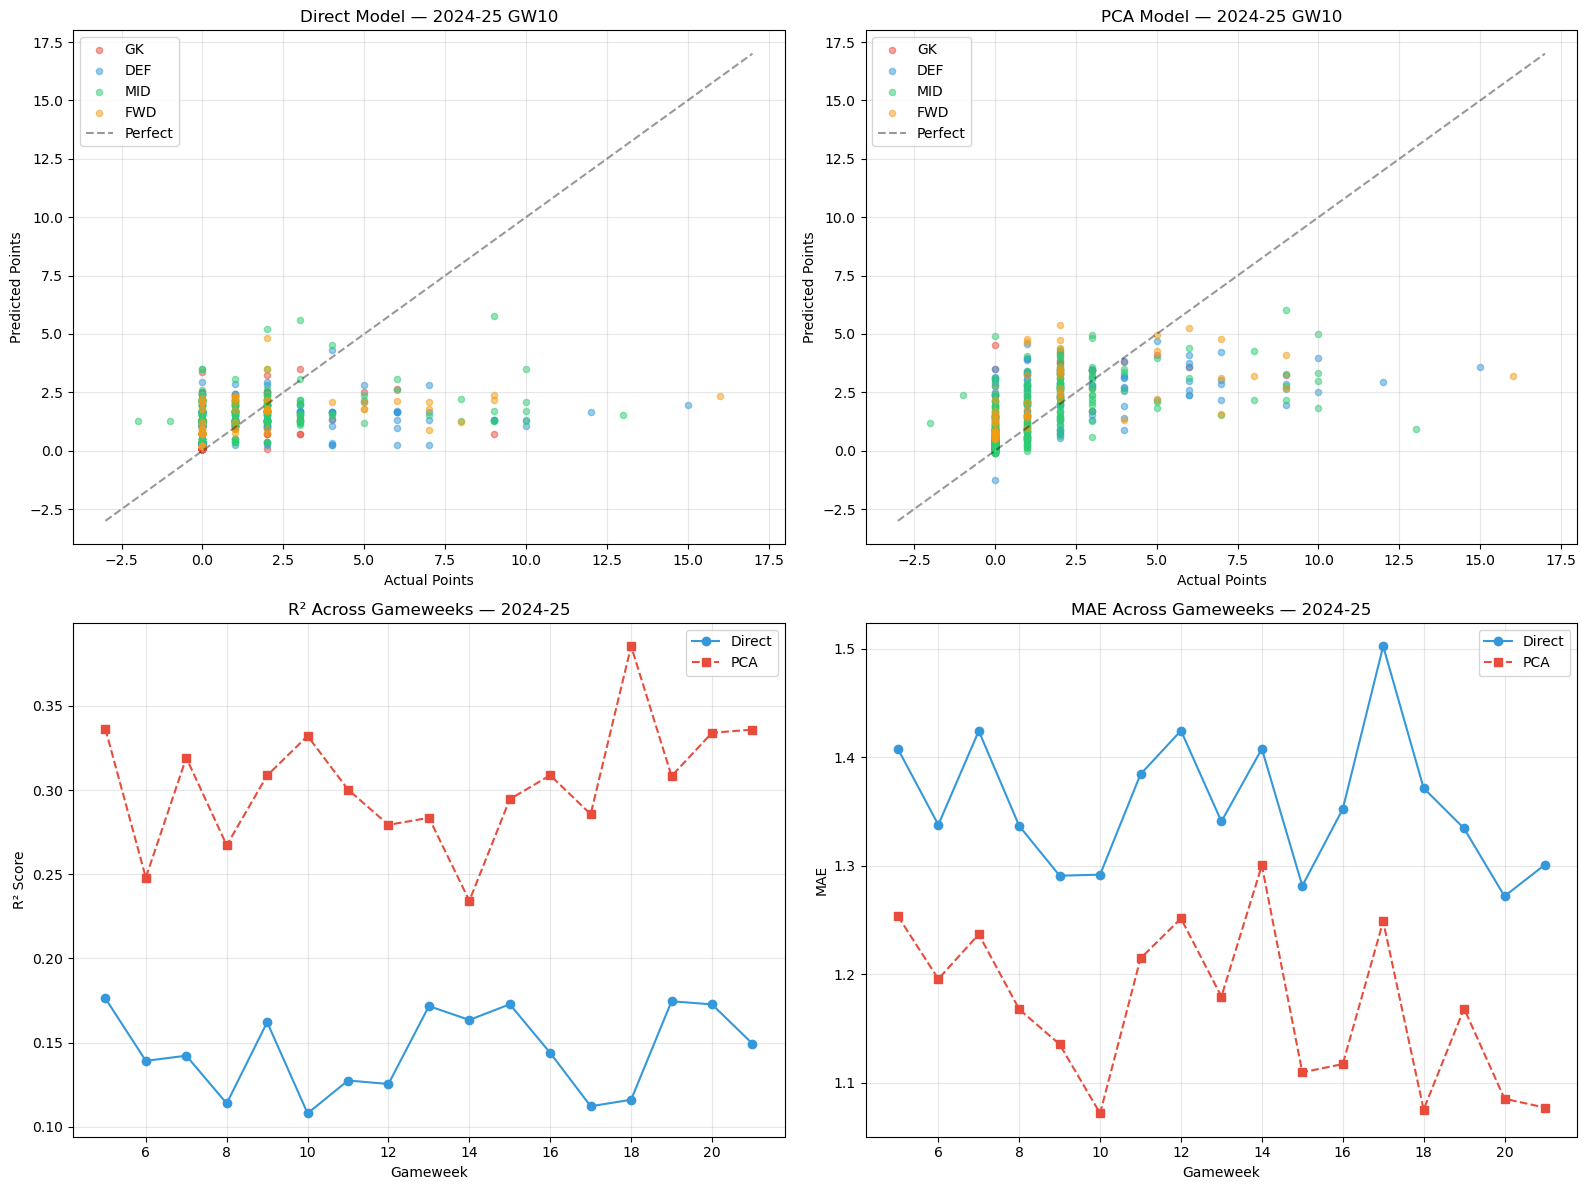

Saved to prediction_results.png


In [32]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ── Plot 1: Predicted vs Actual scatter (Direct model) ───────────────
ax = axes[0, 0]
for pos, color in zip(['GK', 'DEF', 'MID', 'FWD'], ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']):
    mask = gw_data['position'] == pos
    ax.scatter(gw_data.loc[mask, 'total_points'], gw_data.loc[mask, 'pred_direct'],
              alpha=0.5, s=20, label=pos, color=color)
lims = [gw_data['total_points'].min()-1, gw_data['total_points'].max()+1]
ax.plot(lims, lims, 'k--', alpha=0.4, label='Perfect')
ax.set_xlabel('Actual Points')
ax.set_ylabel('Predicted Points')
ax.set_title(f'Direct Model — {TARGET_SEASON} GW{TARGET_GW}')
ax.legend()
ax.grid(True, alpha=0.3)

# ── Plot 2: Predicted vs Actual scatter (PCA model) ─────────────────
ax = axes[0, 1]
for pos, color in zip(['GK', 'DEF', 'MID', 'FWD'], ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']):
    mask = gw_data['position'] == pos
    ax.scatter(gw_data.loc[mask, 'total_points'], gw_data.loc[mask, 'pred_pca'],
              alpha=0.5, s=20, label=pos, color=color)
ax.plot(lims, lims, 'k--', alpha=0.4, label='Perfect')
ax.set_xlabel('Actual Points')
ax.set_ylabel('Predicted Points')
ax.set_title(f'PCA Model — {TARGET_SEASON} GW{TARGET_GW}')
ax.legend()
ax.grid(True, alpha=0.3)

# ── Plot 3: Backtest R2 over gameweeks ──────────────────────────────
ax = axes[1, 0]
if not backtest_df.empty:
    ax.plot(backtest_df['GW'], backtest_df['direct_r2'], 'o-', label='Direct', color='#3498db')
    ax.plot(backtest_df['GW'], backtest_df['pca_r2'], 's--', label='PCA', color='#e74c3c')
    ax.set_xlabel('Gameweek')
    ax.set_ylabel('R² Score')
    ax.set_title(f'R² Across Gameweeks — {BACKTEST_SEASON}')
    ax.legend()
    ax.grid(True, alpha=0.3)

# ── Plot 4: Backtest MAE over gameweeks ─────────────────────────────
ax = axes[1, 1]
if not backtest_df.empty:
    ax.plot(backtest_df['GW'], backtest_df['direct_mae'], 'o-', label='Direct', color='#3498db')
    ax.plot(backtest_df['GW'], backtest_df['pca_mae'], 's--', label='PCA', color='#e74c3c')
    ax.set_xlabel('Gameweek')
    ax.set_ylabel('MAE')
    ax.set_title(f'MAE Across Gameweeks — {BACKTEST_SEASON}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('prediction_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to prediction_results.png")

## 9. Error Analysis

In [33]:
# ── Error distribution for Direct model ─────────────────────────────
gw_data['error_direct'] = gw_data['total_points'] - gw_data['pred_direct']

print("Error Distribution (Direct Model):")
print(f"  Mean error:   {gw_data['error_direct'].mean():.3f}")
print(f"  Std error:    {gw_data['error_direct'].std():.3f}")
print(f"  Median error: {gw_data['error_direct'].median():.3f}")

# Biggest overestimates (predicted much higher than actual)
print(f"\nBiggest Overestimates (predicted >> actual):")
overest = gw_data.nsmallest(5, 'error_direct')[['name', 'position', 'team',
                                                  'total_points', 'pred_direct', 'error_direct']]
print(overest.to_string(index=False, float_format='%.2f'))

# Biggest underestimates (actual much higher than predicted)
print(f"\nBiggest Underestimates (actual >> predicted):")
underest = gw_data.nlargest(5, 'error_direct')[['name', 'position', 'team',
                                                  'total_points', 'pred_direct', 'error_direct']]
print(underest.to_string(index=False, float_format='%.2f'))

Error Distribution (Direct Model):
  Mean error:   -0.007
  Std error:    2.123
  Median error: -0.382

Biggest Overestimates (predicted >> actual):
                     name position      team  total_points  pred_direct  error_direct
         Martin Ãdegaard      MID   Arsenal             0         3.52         -3.52
          Kevin De Bruyne      MID  Man City             0         3.50         -3.50
    Alisson Ramses Becker       GK Liverpool             0         3.38         -3.38
Edson Ãlvarez VelÃ¡zquez      MID  West Ham            -2         1.29         -3.29
              Bukayo Saka      MID   Arsenal             2         5.21         -3.21

Biggest Underestimates (actual >> predicted):
                    name position          team  total_points  pred_direct  error_direct
Dominic Solanke-Mitchell      FWD         Spurs            16         2.36         13.64
                Ola Aina      DEF Nott'm Forest            15         1.97         13.03
            Harry Wil

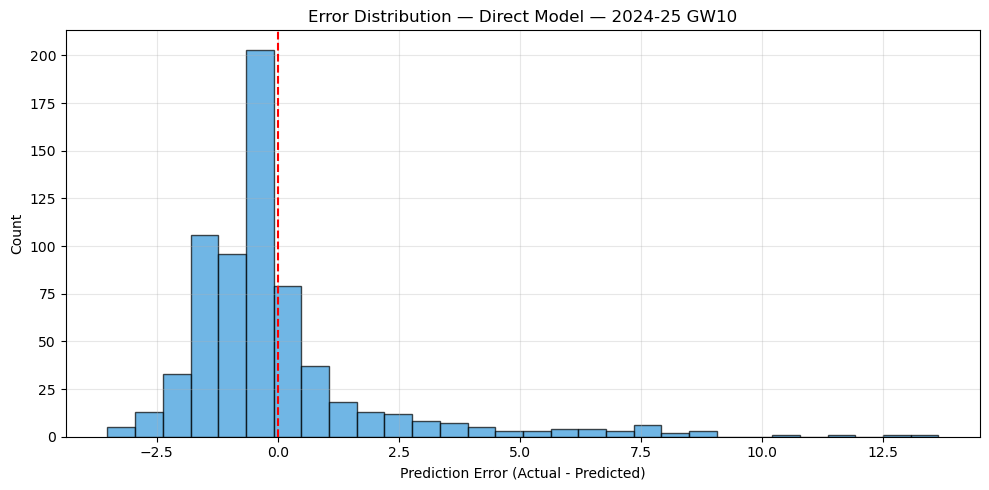

In [34]:
# ── Error histogram ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(gw_data['error_direct'], bins=30, edgecolor='black', alpha=0.7, color='#3498db')
ax.axvline(0, color='red', linestyle='--', linewidth=1.5)
ax.set_xlabel('Prediction Error (Actual - Predicted)')
ax.set_ylabel('Count')
ax.set_title(f'Error Distribution — Direct Model — {TARGET_SEASON} GW{TARGET_GW}')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Export Predictions

In [35]:
# ── Save predictions to CSV ─────────────────────────────────────────
export_cols = ['name', 'position', 'team', 'season', 'GW', 'value',
               'total_points', 'pred_direct', 'pred_pca', 'pred_ensemble']
export_cols = [c for c in export_cols if c in gw_data.columns]

output_file = f'predictions_{TARGET_SEASON.replace("-", "")}_gw{TARGET_GW}.csv'
gw_data[export_cols].to_csv(output_file, index=False)
print(f"Predictions saved to {output_file}")
print(f"Rows: {len(gw_data)}, Columns: {len(export_cols)}")

# Save backtest summary
if not backtest_df.empty:
    backtest_df.to_csv('backtest_summary.csv', index=False)
    print(f"Backtest summary saved to backtest_summary.csv")

Predictions saved to predictions_202425_gw10.csv
Rows: 667, Columns: 10
Backtest summary saved to backtest_summary.csv


## 11. Predict Points for a Single Player

You can provide a player's stats as a dictionary and get a predicted total_points.
The model only needs a **position** and whatever features you can supply — missing features default to 0.

The function below shows which features each position model expects, then lets you pass a stats dict to get a prediction.

In [36]:
def predict_single_player(stats_dict, position, method='direct', model_name=None):
    """
    Predict FPL points for a single player given a dict of stats.
    
    Parameters
    ----------
    stats_dict : dict
        Player stats, e.g. {'value': 80, 'minutes_prev_1': 90, 'bonus_prev_1': 2, ...}
        Any feature not provided defaults to 0.
    position : str
        One of 'GK', 'DEF', 'MID', 'FWD'
    method : str
        'direct' or 'pca'
    model_name : str or None
        Model variant; None uses the best model.
    
    Returns
    -------
    float : predicted total_points
    """
    # Build a single-row DataFrame
    row = {k: [v] for k, v in stats_dict.items()}
    row['position'] = [position]
    df_player = pd.DataFrame(row)
    
    if method == 'direct':
        preds = predict_direct(df_player, position, model_name)
    elif method == 'pca':
        preds = predict_pca(df_player, position, model_name)
    else:
        raise ValueError(f"Unknown method: {method}")
    
    return float(preds[0])


# ── Show which features the model expects per position ──────────────
for pos in ['GK', 'DEF', 'MID', 'FWD']:
    feats = direct_models[pos]['features']
    print(f"\n{pos} — {len(feats)} features (top 30):")
    print(', '.join(feats[:30]))


GK — 1 features (top 30):
value

DEF — 1 features (top 30):
value

MID — 1 features (top 30):
value

FWD — 1 features (top 30):
value


In [37]:
# ── Example: predict points for a single MID ────────────────────────
# Fill in as many features as you have — missing ones default to 0.
# The most impactful features are: value, previous-game stats (minutes, bonus, bps,
# total_points from prev GWs), rolling averages, opponent strength, etc.

example_stats = {
    'value': 100,                    # player price (x10, e.g. 10.0m = 100)
    'minutes_prev_1': 90,            # minutes in last game
    'minutes_prev_2': 90,
    'minutes_prev_3': 85,
    'total_points_prev_1': 8,        # FPL points in last game
    'total_points_prev_2': 3,
    'total_points_prev_3': 6,
    'bonus_prev_1': 2,
    'bps_prev_1': 30,
    'bps_prev_2': 22,
    'goals_scored_prev_1': 1,
    'assists_prev_1': 0,
    'selected': 2500000,             # ownership
    'transfers_in': 150000,
    'transfers_out': 50000,
    'was_home': 1,                   # 1=home, 0=away
    'rolling_avg_total_points_5': 5.4,
    'rolling_avg_minutes_5': 88.0,
    'rolling_avg_bonus_5': 1.2,
}

pred_direct = predict_single_player(example_stats, position='MID', method='direct')
pred_pca    = predict_single_player(example_stats, position='MID', method='pca')

print(f"Example Midfielder Prediction:")
print(f"  Direct model:  {pred_direct:.2f} points")
print(f"  PCA model:     {pred_pca:.2f} points")
print(f"  Average:       {(pred_direct + pred_pca) / 2:.2f} points")

Example Midfielder Prediction:
  Direct model:  3.91 points
  PCA model:     1.31 points
  Average:       2.61 points


In [38]:
# ── Predict for a real player from the dataset ──────────────────────
# This shows the workflow works end-to-end for a specific player.

player_name = 'Mohamed Salah'  # change to any player in the dataset
player_rows = df_clean[df_clean['name'].str.contains(player_name, case=False, na=False)]

if len(player_rows) > 0:
    # Take the most recent row
    player = player_rows.sort_values(['season', 'GW'], ascending=False).iloc[[0]]
    pos = player['position'].values[0]
    
    pred_d = predict_direct(player, pos)[0]
    pred_p = predict_pca(player, pos)[0]
    actual = player['total_points'].values[0]
    
    print(f"Player: {player['name'].values[0]}")
    print(f"Position: {pos} | Season: {player['season'].values[0]} | GW: {player['GW'].values[0]}")
    print(f"Actual Points:    {actual}")
    print(f"Direct Predicted: {pred_d:.2f}")
    print(f"PCA Predicted:    {pred_p:.2f}")
else:
    print(f"Player '{player_name}' not found in dataset.")

Player: Mohamed Salah
Position: MID | Season: 2025-26 | GW: 9
Actual Points:    6
Direct Predicted: 5.62
PCA Predicted:    5.32
